#IMDB Sentiment Analysis


In [1]:
pip install tf-nightly

     |████████████████████████████████| 324.8MB 31kB/s 
     |████████████████████████████████| 460kB 46.6MB/s 
     |████████████████████████████████| 6.7MB 43.4MB/s 


In [2]:
import matplotlib.pyplot as plt
import os
import re
import shutil
import string
import tensorflow as tf

from tensorflow.keras import layers
from tensorflow.keras import losses
from tensorflow.keras import preprocessing
from tensorflow.keras.layers.experimental.preprocessing import TextVectorization

In [3]:
print(tf.__version__)

2.4.0-dev20200725


#1. Load and preping the Data


In [4]:
url = "https://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz"

dataset = tf.keras.utils.get_file("aclImdb_v1.tar.gz", url,
                                  untar=True, cache_dir='.',
                                  cache_subdir= '')

dataset_dir = os.path.join(os.path.dirname(dataset), 'aclImdb' )

84131840/84125825 [==============================] - 5s 0us/step


In [5]:
os.listdir(dataset_dir)

['README', 'imdb.vocab', 'imdbEr.txt', 'train', 'test']

In [6]:
train_dir = os.path.join(dataset_dir, 'train')
os.listdir(train_dir)

['unsupBow.feat',
 'pos',
 'urls_unsup.txt',
 'neg',
 'urls_neg.txt',
 'unsup',
 'labeledBow.feat',
 'urls_pos.txt']

In [7]:
pos = os.path.join(train_dir, 'pos')
# os.listdir(pos)

In [8]:
sample_pos_review = os.path.join(pos, '5567_7.txt')
with open(sample_pos_review)as f:
  print(f.read())

And I'll tell you why: whoever decided to edit this movie to make it suitable for television was very ill-advised. EVERYTHING CONCERNING DRUGS IS CUT OUT AND COVERED UP!!! How do they do it, you might ask? Well, they don't do it very well, that's for sure. Anyway, instead of the marijuana which Cheech and Chong are supposed to have in their possession, they are said to have diamonds! Still, the characters go around in a haze of marijuana smoke stoning others along their way with no explanation whatsoever!


#Loading the dataset into right format
# => Right format




```

main_directory/
...class_a/
......a_text_1.txt
......a_text_2.txt
...class_b/
......b_text_1.txt
......b_text_2.txt
```




In [9]:
#There need to be only two folders
# because this is a binary classification task

# Removing unsup
remove_dir = os.path.join(train_dir, 'unsup')
shutil.rmtree(remove_dir)

In [11]:
#Creating a validation set
batch_size = 32
seed = 42

#only availabel through tf-nightly
              
raw_train_ds = tf.keras.preprocessing.text_dataset_from_directory(
    'aclImdb/train',
    batch_size = batch_size,
    validation_split = 0.2,
    subset= 'training',
    seed = seed
)

Found 25000 files belonging to 2 classes.
Using 20000 files for training.


In [12]:
for text_batch, label_batch in raw_train_ds.take(1):
  for i in range(5):
    print("review", text_batch.numpy()[i])
    print("Label", label_batch.numpy()[i])

review b'"Pandemonium" is a horror movie spoof that comes off more stupid than funny. Believe me when I tell you, I love comedies. Especially comedy spoofs. "Airplane", "The Naked Gun" trilogy, "Blazing Saddles", "High Anxiety", and "Spaceballs" are some of my favorite comedies that spoof a particular genre. "Pandemonium" is not up there with those films. Most of the scenes in this movie had me sitting there in stunned silence because the movie wasn\'t all that funny. There are a few laughs in the film, but when you watch a comedy, you expect to laugh a lot more than a few times and that\'s all this film has going for it. Geez, "Scream" had more laughs than this film and that was more of a horror film. How bizarre is that?<br /><br />*1/2 (out of four)'
Label 0
review b"David Mamet is a very interesting and a very un-equal director. His first movie 'House of Games' was the one I liked best, and it set a series of films with characters whose perspective of life changes as they get into 

In [27]:
print("Label 0 corresponds to", raw_train_ds.class_names[0])
print("Label 1 corresponds to", raw_train_ds.class_names[1])


Label 0 corresponds to neg
Label 1 corresponds to pos


In [28]:
raw_val_ds = tf.keras.preprocessing.text_dataset_from_directory(
    'aclImdb/train',
    batch_size=batch_size,
    validation_split = 0.2,
    subset = 'validation',
    seed=seed
)

Found 25000 files belonging to 2 classes.
Using 5000 files for validation.


In [30]:
raw_test_ds = tf.keras.preprocessing.text_dataset_from_directory(
    'aclImdb/test',
    batch_size=batch_size
)

Found 25000 files belonging to 2 classes.


In [31]:
for text_batch, label_batch in raw_test_ds.take(1):
  for i in range(5):
    print("review", text_batch.numpy()[i])
    print("Label", label_batch.numpy()[i])

review b'I think i would rather have my piles clipped with a pair of rusty clippers than bear another 5 minutes of this movie. In fact i cannot even be bothered to go in to detail! Not sure how they managed to get the needles into the wooden actors to cure them! Better off for all concerned if they had just nuked the island after finding out about the virus, that way it would have lasted as long as the commercial break, and we could have moved on with our lives. Plus one more thing was this rubbish commissioned by the god channel? As all they seemed to do was praise the bleeding lord most of the time. Avoid like the plague! In fact i would prefer it!'
Label 0
review b"Roy Thinnes and Joan Hackett are superb in this 1970 melodrama. The lush settings, the haunting music, and plot twists make it a truly interesting film. I had seen it when it first came out on TV. Once more it aired when I had a VCR, but I did not have a chance to tape it. Would love it on VHS if someone has a copy. Apart

#Standardization
is a way of preprocessing text removing the HTML elements and simplying data

#Tokenization
Refers to splitting data into tokens

Example: splitting the sentence into words on empty spaces

#Vectorization
converts the tokens into a vector to connect it to a neural network


In [33]:
#the default TextVectorization layed does not strip HTML
# So we are going to make an custom function
def custom_standardization(input_data):
  lowercase = tf.strings.lower(input_data)
  stripped_html = tf.strings.regex_replace(lowercase, '<br />', ' ')
  return tf.strings.regex_replace(stripped_html,
                                  '[%s]' % re.escape(string.punctuation),
                                  '')

In [34]:
#sequence_length will pad or truncate sequences to exactly sequence_length values
max_features = 10000
sequence_length = 250


vectorize_layer = TextVectorization(
    standardize = custom_standardization,
    max_tokens = max_features,
    output_mode = 'int',
    output_sequence_length = sequence_length)

In [37]:
#adapt is similar to the fit method
train_text = raw_train_ds.map(lambda x, y:x) #make a text-only dataset
vectorize_layer.adapt(train_text)

In [39]:
def vectorize_text(text, label):
  text = tf.expand_dims(text, -1)
  return vectorize_layer(text), label

In [40]:
len(b'Silent Night, Deadly Night 5 is the very last of the series, and like part 4, it\'s unrelated to the first three except by title and the fact that it\'s a Christmas-themed horror flick.<br /><br />Except to the oblivious, there\'s some obvious things going on here...Mickey Rooney plays a toymaker named Joe Petto and his creepy son\'s name is Pino. Ring a bell, anyone? Now, a little boy named Derek heard a knock at the door one evening, and opened it to find a present on the doorstep for him. Even though it said "don\'t open till Christmas", he begins to open it anyway but is stopped by his dad, who scolds him and sends him to bed, and opens the gift himself. Inside is a little red ball that sprouts Santa arms and a head, and proceeds to kill dad. Oops, maybe he should have left well-enough alone. Of course Derek is then traumatized by the incident since he watched it from the stairs, but he doesn\'t grow up to be some killer Santa, he just stops talking.<br /><br />There\'s a mysterious stranger lurking around, who seems very interested in the toys that Joe Petto makes. We even see him buying a bunch when Derek\'s mom takes him to the store to find a gift for him to bring him out of his trauma. And what exactly is this guy doing? Well, we\'re not sure but he does seem to be taking these toys apart to see what makes them tick. He does keep his landlord from evicting him by promising him to pay him in cash the next day and presents him with a "Larry the Larvae" toy for his kid, but of course "Larry" is not a good toy and gets out of the box in the car and of course, well, things aren\'t pretty.<br /><br />Anyway, eventually what\'s going on with Joe Petto and Pino is of course revealed, and as with the old story, Pino is not a "real boy". Pino is probably even more agitated and naughty because he suffers from "Kenitalia" (a smooth plastic crotch) so that could account for his evil ways. And the identity of the lurking stranger is revealed too, and there\'s even kind of a happy ending of sorts. Whee.<br /><br />A step up from part 4, but not much of one. Again, Brian Yuzna is involved, and Screaming Mad George, so some decent special effects, but not enough to make this great. A few leftovers from part 4 are hanging around too, like Clint Howard and Neith Hunter, but that doesn\'t really make any difference. Anyway, I now have seeing the whole series out of my system. Now if I could get some of it out of my brain. 4 out of 5.')

2453

In [41]:
text_batch, label_batch = next(iter(raw_train_ds))
first_review, first_label = text_batch[0], label_batch[0]


In [42]:
print("review,", first_review)

review, tf.Tensor(b'Belmondo is a tough cop. He goes after a big-time drug dealer (played by Henry Silva, normally a great villain - see "Sharky\'s Machine"; but here he is clearly dubbed, and because of that he lacks his usual charisma). He goes to the scuzziest places of Paris and Marseilles, asks for some names, beats up some people, gets the names, goes to more scuzzy places, asks for more names, beats up more people, etc. The whole movie is punch after punch after punch. It seems that the people who made it had no other ambition than to create the French equivalent of "Dirty Harry". Belmondo, who was 50 here, does perform some good stunts at the beginning; apart from those, "Le Marginal" is a violent, episodic, trite, shallow and forgettable cop movie. (*1/2)', shape=(), dtype=string)


In [43]:
print("Label", raw_train_ds.class_names[first_label])

Label neg


In [44]:
print("vectorized review", vectorize_text(first_review, first_label))

vectorized review (<tf.Tensor: shape=(1, 250), dtype=int64, numpy=
array([[   1,    7,    4, 1233, 1021,   27,  261,  101,    4,    1, 1525,
        6992,  248,   32, 1488,    1, 1659,    4,   86, 1011,   67,    1,
        1707,   18,  128,   27,    7,  688, 2396,    3,   84,    5,   12,
          27, 1453,   24,  616, 3314,   27,  261,    6,    2,    1, 1329,
           5, 1371,    3,    1, 1581,   15,   46, 1356, 3612,   56,   46,
          79,  201,    2, 1356,  261,    6,   50,    1, 1329, 1581,   15,
          50, 1356, 3612,   56,   50,   79,  532,    2,  211,   17,    7,
        2851,  101, 2851,  101, 2851,    9,  180,   12,    2,   79,   36,
          90,    9,   66,   57,   78, 5415,   70,    6,  916,    2,  800,
        4891,    5, 1678, 1347,    1,   36,   13, 1732,  128,  120, 3078,
          46,   49, 3274,   31,    2,  435,  948,   35,  143, 3519,    1,
           7,    4, 1097, 9578, 3092, 2056,    3, 2512, 1021,   17, 1105,
           0,    0,    0,    0,    0,    0,  

In [47]:
print("9578 ---> ",vectorize_layer.get_vocabulary()[9578])
print(" 3092 ---> ",vectorize_layer.get_vocabulary()[3092])
print('Vocabulary size: {}'.format(len(vectorize_layer.get_vocabulary())))


9578 --->  episodic
 3092 --->  trite
Vocabulary size: 10000


In [48]:
#apply Text vectorization layer to train, validation and test
train_ds = raw_train_ds.map(vectorize_text)
val_ds = raw_val_ds.map(vectorize_text)
test_ds = raw_test_ds.map(vectorize_text)


#An important step to keep in mind so that I/O does not become blocking

.cache() keeps data in memory after it is loaded of the disk. This will ensure the dataset will not become a bottleneck while training

.prefetch() overlaps data preprocessing and model execution while training (more efficent when your dataset is very large)


In [49]:
AUTOTUNE = tf.data.experimental.AUTOTUNE

train_ds = train_ds.cache().prefetch(buffer_size = AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size = AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size = AUTOTUNE)

#2. Creating a model

In [50]:
embedding_dim = 16

In [91]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, Dropout,GlobalAveragePooling1D,Dense
model = Sequential()

model.add(Embedding(max_features + 1, embedding_dim))
model.add(Dropout(0.2))
model.add(GlobalAveragePooling1D())
model.add(Dropout(0.2))
model.add(Dense(1))

model.summary()


Model: "sequential_2"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
embedding_2 (Embedding)      (None, None, 16)          160016    
_________________________________________________________________
dropout_4 (Dropout)          (None, None, 16)          0         
_________________________________________________________________
global_average_pooling1d_2 ( (None, 16)                0         
_________________________________________________________________
dropout_5 (Dropout)          (None, 16)                0         
_________________________________________________________________
dense_2 (Dense)              (None, 1)                 17        
Total params: 160,033
Trainable params: 160,033
Non-trainable params: 0
_________________________________________________________________


In [92]:
#Loss function and optimizer
model.compile(loss = losses.BinaryCrossentropy(from_logits=True),
              optimizer='adam',
              metrics=tf.metrics.BinaryAccuracy(threshold=0.0))

In [93]:
history = model.fit(train_ds,
                    validation_data = val_ds,
                    epochs = 10)

Epoch 1/10
625/625 [==============================] - 4s 7ms/step - loss: 0.6836 - binary_accuracy: 0.6054 - val_loss: 0.6173 - val_binary_accuracy: 0.7720
Epoch 2/10
625/625 [==============================] - 4s 6ms/step - loss: 0.5815 - binary_accuracy: 0.7828 - val_loss: 0.4999 - val_binary_accuracy: 0.8190
Epoch 3/10
625/625 [==============================] - 4s 6ms/step - loss: 0.4674 - binary_accuracy: 0.8322 - val_loss: 0.4212 - val_binary_accuracy: 0.8452
Epoch 4/10
625/625 [==============================] - 4s 6ms/step - loss: 0.3920 - binary_accuracy: 0.8604 - val_loss: 0.3749 - val_binary_accuracy: 0.8596
Epoch 5/10
625/625 [==============================] - 4s 6ms/step - loss: 0.3448 - binary_accuracy: 0.8755 - val_loss: 0.3461 - val_binary_accuracy: 0.8674
Epoch 6/10
625/625 [==============================] - 4s 6ms/step - loss: 0.3126 - binary_accuracy: 0.8861 - val_loss: 0.3268 - val_binary_accuracy: 0.8710
Epoch 7/10
625/625 [==============================] - 4s 6ms/ste

#3. Evaluate the model

In [94]:
loss, accuracy = model.evaluate(test_ds)

print("Loss: ", loss)
print("Accuracy: ", accuracy)

782/782 [==============================] - 1s 1ms/step - loss: 0.3103 - binary_accuracy: 0.8738
Loss:  0.31025776267051697
Accuracy:  0.8737599849700928


In [95]:
history_dict = history.history
history_dict.keys()

dict_keys(['loss', 'binary_accuracy', 'val_loss', 'val_binary_accuracy'])

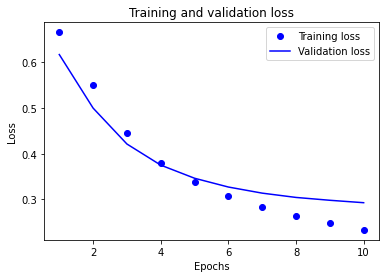

In [96]:
acc = history_dict['binary_accuracy']
val_acc = history_dict['val_binary_accuracy']
loss = history_dict['loss']
val_loss = history_dict['val_loss']

epochs = range(1, len(acc) + 1)

# "bo" is for "blue dot"
plt.plot(epochs, loss, 'bo', label='Training loss')
# b is for "solid blue line"
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()


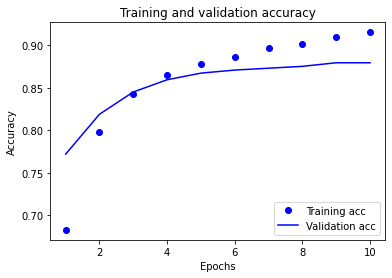

In [97]:
plt.plot(epochs, acc, 'bo', label='Training acc')
plt.plot(epochs, val_acc, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')

plt.show()


#4. Exporting the model

In [99]:
export_model = Sequential([
                           vectorize_layer,
                           model,
                           layers.Activation('sigmoid')
])

export_model.compile(
    loss = losses.BinaryCrossentropy(from_logits=False), optimizer = 'adam',
    metrics= ['accuracy']
)

loss, accuracy = export_model.evaluate(raw_test_ds)
print(accuracy)

782/782 [==============================] - 10s 13ms/step - loss: 0.3062 - accuracy: 0.8756
0.8737599849700928


In [100]:
model.save('my_model.h5')